# 03 Shots Data

Calculate state-specific and combined low-lying QSE errors across the fixed overlap-threshold ladder.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd

from config import PROCESSED_DATAFRAMES_DIR
from notebook_utils.analysis import get_max_states
from notebook_utils.general import parse_active_space, save_figure
from notebook_utils.graphs import plot_best_threshold_heatmap, plot_error_scaling_regression, plot_threshold_shot_errors, show_scrollable_figs
from notebook_utils.mat_fn import dimension_solve, threshold_ladder_solve

SHOTS_DATAFRAME_PATH = PROCESSED_DATAFRAMES_DIR / "shots_qse_data.pkl"
df_shots = pd.read_pickle(SHOTS_DATAFRAME_PATH)

In [2]:
MEAN_KEYS = ["active_space", "ansatz", "n_shots", "molecule"]
SECTOR_STATES = {"singlet": 2, "triplet": 6}
FIXED_THRESHOLDS = np.logspace(-4, 0, 41)

mean_error_rows = []

# Group the entries by unique active space, ansatz, nshots and molecule
for key, df_group in df_shots.groupby(MEAN_KEYS, sort=True):
    active_space, ansatz, n_shots, molecule = key
    singlet_dimension, triplet_dimension = get_max_states(parse_active_space(active_space))
    dimensions = {"singlet": singlet_dimension, "triplet": triplet_dimension}
    state_errors = []

    for expansion, max_sector_states in SECTOR_STATES.items():
        df_expansion = df_group[df_group["expansion"] == expansion]
        dimension = dimensions[expansion]
        # num sector states is the number of states we retain, min of 2/6 or dimensions
        num_sector_states = min(dimension, max_sector_states)
        first_row = df_expansion.iloc[0]

        # Solve SV energies once first 
        sv_energies = dimension_solve(first_row["H_sv"], first_row["S_sv"], dimension)[0]
        sv_energies = sv_energies[:num_sector_states]
        # Solve shot energies from the threshold ladder
        shot_energies = np.asarray([
            threshold_ladder_solve(row.H_shots, row.S_shots, FIXED_THRESHOLDS, num_sector_states)
            for row in df_expansion.itertuples(index=False)
        ])

        # Group triplet terms
        if expansion == "triplet":
            sv_energies = sv_energies.reshape(-1, 3).mean(axis=-1)
            shot_energies = shot_energies.reshape(*shot_energies.shape[:-1], -1, 3).mean(axis=-1)

        repeat_errors = 1000 * np.abs(shot_energies - sv_energies)
        state_errors.append(repeat_errors.mean(axis=0))

    mean_error_rows.append({
        **dict(zip(MEAN_KEYS, key)),
        "mean_error": np.concatenate(state_errors, axis=1).mean(axis=1),
    })

df_mean_errors = pd.DataFrame(mean_error_rows)

In [3]:
df_mean_errors

,active_space,ansatz,n_shots,molecule,mean_error
0,2e2o,UCCSD,1000,Acetamide,"[184.4548894527037, 184.4548894527037, 184.454..."
1,2e2o,UCCSD,1000,Acetone,"[41.63093502588898, 41.63093502588898, 41.6309..."
2,2e2o,UCCSD,1000,Adenine,"[66.93554748039598, 66.93554748039598, 66.9355..."
3,2e2o,UCCSD,1000,Benzene,"[97.0058024631309, 97.0058024631309, 97.005802..."
4,2e2o,UCCSD,1000,Benzoquinone,"[342.9732346790331, 342.9732346790331, 342.973..."
...,...,...,...,...,...
1955,6e6o,UCCSD,1000000,Pyrrole,"[646.6847815674371, 557.0015345845242, 505.335..."
1956,6e6o,UCCSD,1000000,Tetrazine,"[819.9730046565705, 722.3995966736595, 518.435..."
1957,6e6o,UCCSD,1000000,Thymine,"[366.98949822676923, 354.9758807863924, 320.65..."
1958,6e6o,UCCSD,1000000,Triazine,"[813.8063673501663, 765.9791247695723, 726.712..."


## Error against Thresholding and Shot Count


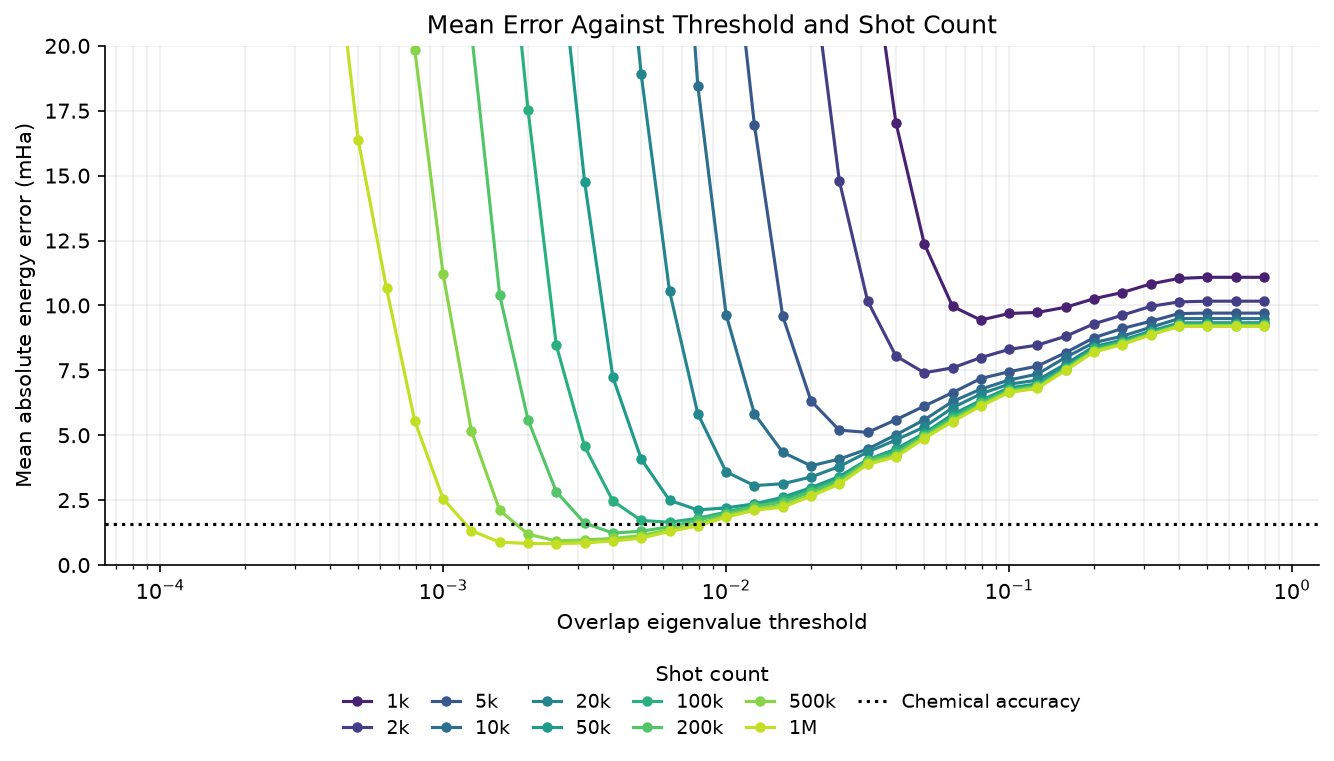

In [4]:
df_6e6o_errors = df_mean_errors[df_mean_errors["active_space"] == "4e4o"]
shot_threshold_errors = {}

for n_shots in sorted(df_6e6o_errors["n_shots"].unique()):
    df_shot_count = df_6e6o_errors[df_6e6o_errors["n_shots"] == n_shots]
    error_vectors = np.stack(df_shot_count["mean_error"])
    shot_threshold_errors[int(n_shots)] = error_vectors.mean(axis=0)

threshold_shot_figure = plot_threshold_shot_errors(shot_threshold_errors, FIXED_THRESHOLDS)
save_figure(threshold_shot_figure, "shots", "threshold_shot_error_6e6o")
show_scrollable_figs([threshold_shot_figure])

## Best threshold


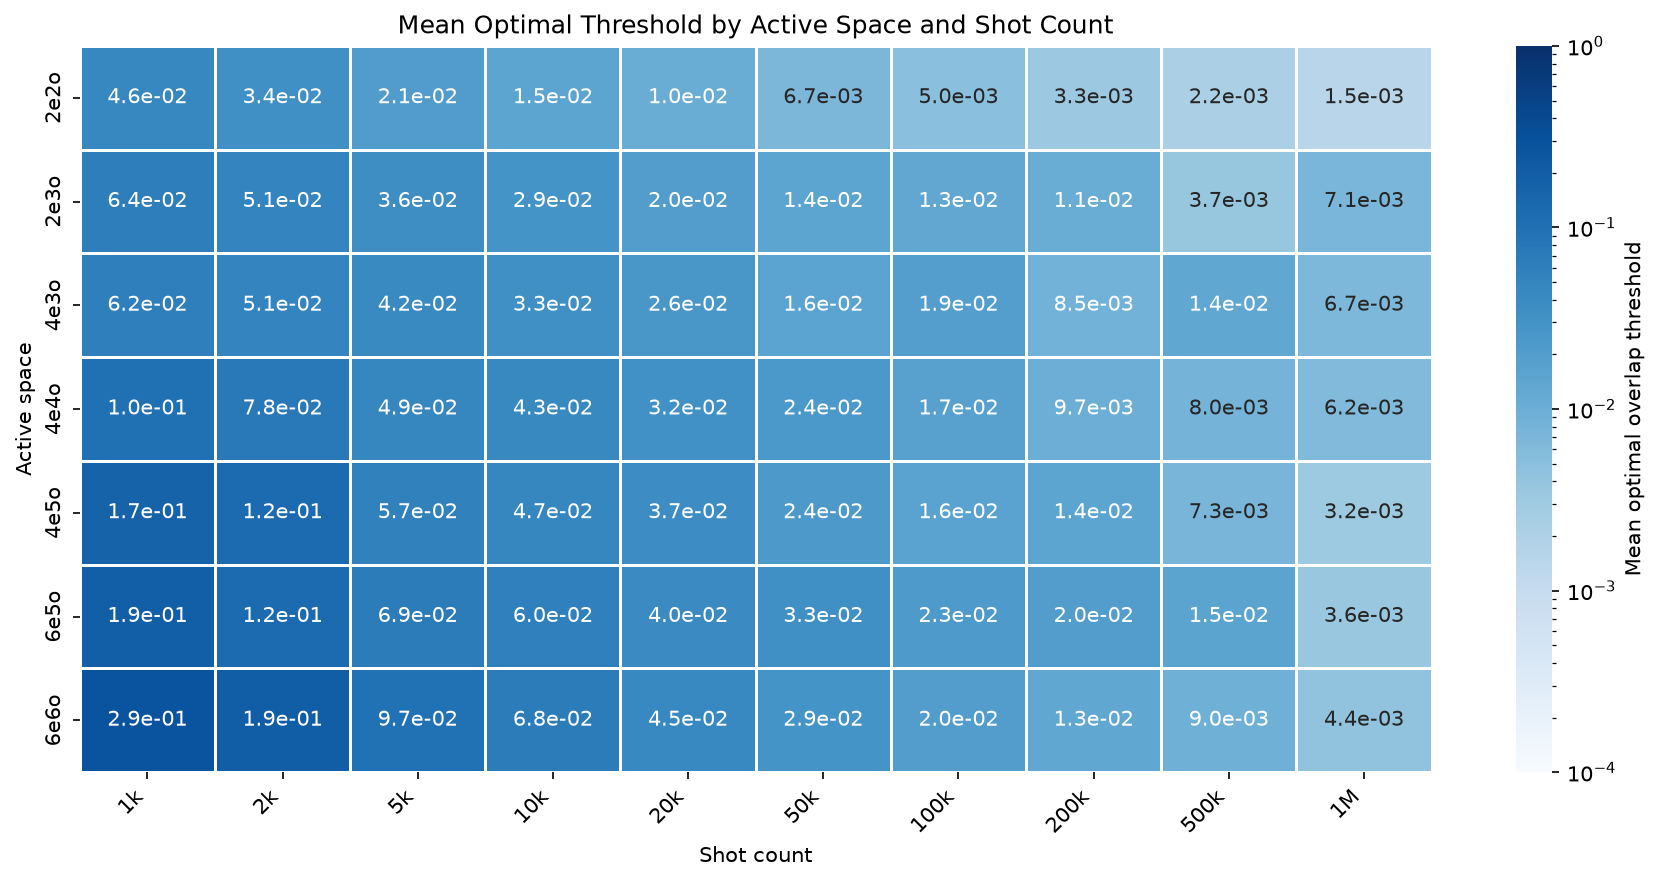

In [5]:
active_spaces = sorted(df_mean_errors["active_space"].unique(), key=parse_active_space)
shot_counts = sorted(df_mean_errors["n_shots"].unique())
best_threshold_data = {}

for active_space in active_spaces:
    df_active = df_mean_errors[df_mean_errors["active_space"] == active_space]
    best_threshold_data[active_space] = {}

    for n_shots in shot_counts:
        df_shot_count = df_active[df_active["n_shots"] == n_shots]
        molecule_thresholds = [
            FIXED_THRESHOLDS[np.nanargmin(errors)]
            for errors in df_shot_count["mean_error"]
        ]
        best_threshold_data[active_space][int(n_shots)] = np.mean(molecule_thresholds)

best_threshold_figure = plot_best_threshold_heatmap(best_threshold_data)
save_figure(best_threshold_figure, "shots", "best_threshold_heatmap")
show_scrollable_figs([best_threshold_figure])

## Active space scaling


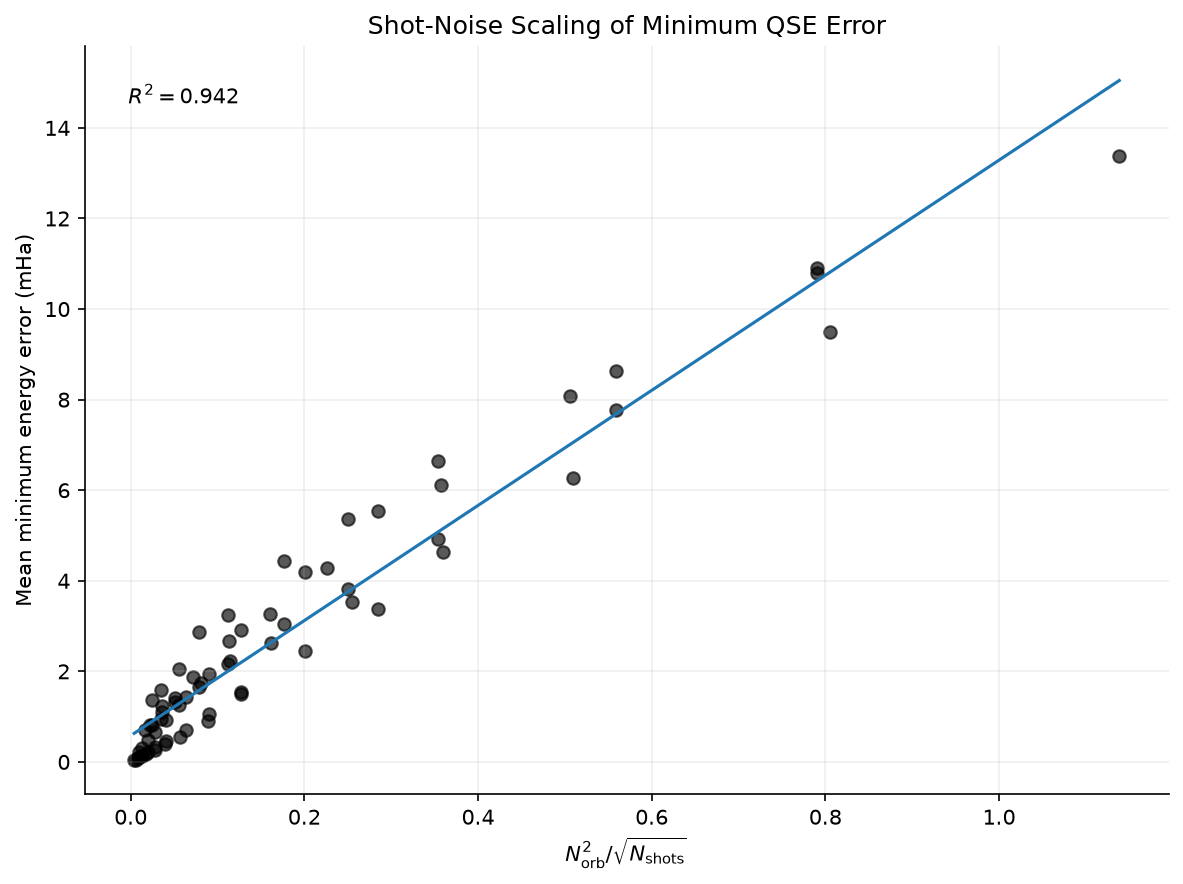

In [6]:
lowest_error_data = {}

for active_space in active_spaces:
    df_active = df_mean_errors[df_mean_errors["active_space"] == active_space]
    lowest_error_data[active_space] = {}

    for n_shots in shot_counts:
        df_shot_count = df_active[df_active["n_shots"] == n_shots]
        molecule_errors = [np.nanmin(errors) for errors in df_shot_count["mean_error"]]
        lowest_error_data[active_space][int(n_shots)] = np.mean(molecule_errors)

scaling_points = []
for active_space, shot_errors in lowest_error_data.items():
    _, num_orbitals = parse_active_space(active_space)

    for n_shots, mean_error in shot_errors.items():
        scaling_coordinate = num_orbitals**2 / np.sqrt(n_shots)
        scaling_points.append((scaling_coordinate, mean_error))

scaling_figure = plot_error_scaling_regression(scaling_points)
save_figure(scaling_figure, "shots", "active_space_shot_scaling_regression")
show_scrollable_figs([scaling_figure])